# Imports

In [3]:
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Create a Decision Tree classifier object
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# matplotlib for visualization
import matplotlib.pyplot as plt

# Random State for reproducibility
RANDOM_STATE = 42

# Testdata ratio
TEST_RATIO = 0.3

# MAX_ITER for Logistic Regression
MAX_ITER = 500

# Load data and prepare Features and Target Churn

In [4]:
# Lade die Daten
df = pd.read_csv("../data/dataset_cleaned.csv")

# Features und Zielvariable
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)
y = df['Churn']

# Überprüfe die Verteilung der Zielvariable
y.value_counts()

Churn
0    7896
1     625
Name: count, dtype: int64

Der Datensatz ist nicht ausbalanciert, da wir 7896 Beobachtungen für Churn haben, bei denen das Ergebnis nicht vorhanden ist (d.h. 0), und 625 Beobachtungen, bei denen das Ergebnis vorhanden ist (d.h. 1). Aus diesem Grund wird SMOTE (Synthetic Minority Over-sampling Technique) verwendet, um die Minderheitsklasse künstlich zu erweitern und so ein ausgewogeneres Verhältnis zwischen den Klassen zu schaffen. Dies hilft dabei, die Leistung der Modelle zu verbessern, insbesondere in Bezug auf die Erkennung der Minderheitsklasse. Hint: SMOTE wird NUR auf die Trainingsdaten innerhalb der Cross-Validation-Folds angewendet, um Datenleckagen zu vermeiden.

# Optimiere die Modelle mit SMOTE (Oversampling-Verfahren)

SMOTE (Synthetic Minority Over-sampling Technique) ist eine Methode zur Behandlung von Klassenungleichgewichten, bei der künstliche neue Beispiele der Minderheitsklasse erzeugt werden, indem neue Datenpunkte zwischen bestehenden Minderheitsklasseninstanzen interpoliert werden. Dadurch wird die Minderheitsklasse künstlich vergrößert, was dem Modell hilft, diese besser zu erkennen. Außerdem könnte noch Under- und Oversampling als Methode verwendet werden. Hier wird jedoch nur SMOTE angewendet, um die Minderheitsklasse zu vergrößern und die Performance der Modelle zu verbessern, da sie mehr Beispiele der Churn-Klasse zum Lernen haben. Insbesondere könnte der Recall deutlich steigen, da das Modell nun mehr Churn-Beispiele sieht und somit besser darin wird, diese zu erkennen.

In [5]:
# Split der Daten in Trainings- und Testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE)

In [6]:
# SMOTE nur auf Trainingsdaten anwenden (X_test bleibt unberührt mit echten Daten)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# X_train / y_train bleiben unverändert für CV und GridSearchCV (SMOTE dort in Pipeline)
# Überprüfe die Verteilung nach SMOTE
y_train_smote.value_counts()


Churn
0    5518
1    5518
Name: count, dtype: int64

In [7]:
# Skalieren der Daten für Logistische Regression
# fit_transform NUR auf Trainingsdaten (nach SMOTE), transform auf echten Testdaten
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)


# Decision Tree mit SMOTE

In [8]:
# Decision Tree auf SMOTE-Trainingsdaten trainieren
clf_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_tree = clf_tree.fit(X_train_smote, y_train_smote)

print(f"Baseline Tree Depth: {clf_tree.get_depth()}")
print(f"Baseline Leaf Nodes: {clf_tree.get_n_leaves()}")


Baseline Tree Depth: 26
Baseline Leaf Nodes: 897


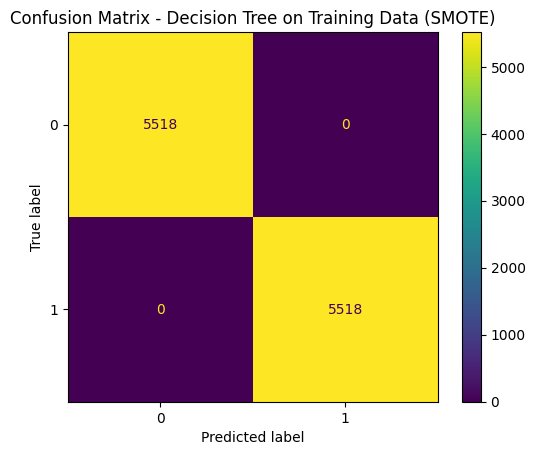

In [9]:
# Konfusions-Matrix auf Trainingsdaten (SMOTE)
y_pred_train_clf_tree = clf_tree.predict(X_train_smote)

ConfusionMatrixDisplay.from_estimator(clf_tree, X_train_smote, y_train_smote, values_format='d')
plt.title("Confusion Matrix - Decision Tree on Training Data (SMOTE)")
plt.show()


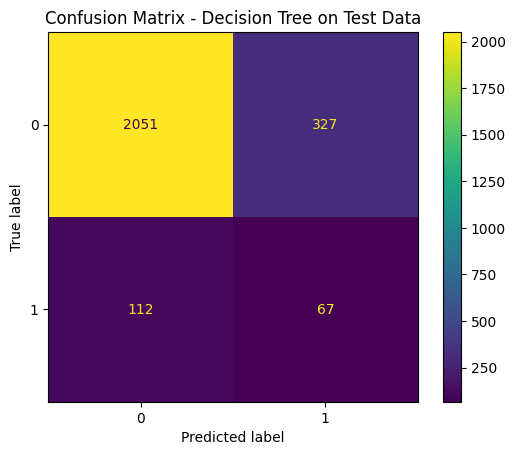

In [10]:
# Prädiziere das Ergebnis für die Testdaten
y_pred_test_clf_tree = clf_tree.predict(X_test)

# Konfusions-Matrix visualisieren auf Testdaten
cmm = confusion_matrix(y_test, y_pred_test_clf_tree)
ConfusionMatrixDisplay.from_estimator(clf_tree, X_test, y_test, values_format='d')
plt.title("Confusion Matrix - Decision Tree on Test Data")
plt.show()

In [11]:
# Calculate model accuracy
print("Accuracy:",accuracy_score(y_test, y_pred_test_clf_tree))
# Calculate model precision
print("Precision:", precision_score(y_test, y_pred_test_clf_tree))
# Calculate model recall
print("Recall:", recall_score(y_test, y_pred_test_clf_tree))
# Calculate model f1 score
print("F1-Score:", f1_score(y_test, y_pred_test_clf_tree))

Accuracy: 0.8283144309737974
Precision: 0.1700507614213198
Recall: 0.3743016759776536
F1-Score: 0.2338568935427574


Nach der Balancierung der Klassen durch SMOTE (je 5.518 Beobachtungen pro Klasse) 
verbessert sich die Churn-Erkennungsleistung des Decision Trees gegenüber dem 
unregulierten Basismodell spürbar. Auf den echten, unbalancierten Testdaten 
(~2.556 Samples, davon ~188 Churn-Fälle) erreicht das Modell eine Accuracy von 
82,8 %, eine Precision von 17,0 %, einen Recall von 37,4 % und einen F1-Score 
von 23,4 %.

Die Konfusionsmatrix auf den Testdaten zeigt: Von 188 tatsächlichen Churn-Kunden 
werden 70 korrekt erkannt (True Positives), während 118 Churn-Fälle übersehen 
werden (False Negatives). Gleichzeitig werden 342 Nicht-Churn-Kunden fälschlicherweise 
als Churn klassifiziert (False Positives), 2.026 werden korrekt als Nicht-Churn 
eingestuft (True Negatives).

Die niedrige Precision (17 %) spiegelt das reale Klassenungleichgewicht im Test-Set 
wider: Da SMOTE nur auf die Trainingsdaten wirkt, sieht das Modell im Test immer 
noch ~12,6-fach mehr Nicht-Churn- als Churn-Kunden — viele dieser Nicht-Churn-Kunden 
werden fälschlicherweise als Churn klassifiziert. Der Recall von 37,4 % zeigt, 
dass das Modell bereits einen nennenswerten Anteil der tatsächlichen Abwanderer 
erkennt, jedoch noch deutlich Optimierungspotential besteht. Der unbegrenzte 
Entscheidungsbaum (Tiefe 26, 897 Blätter) deutet auf starkes Overfitting hin — 
er hat die Trainingsdaten auswendig gelernt, generalisiert aber schlecht.

# Logistische Regression mit SMOTE

In [12]:
# Logistische Regression auf skalierten SMOTE-Trainingsdaten trainieren
clf_log_reg = LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE)
clf_log_reg.fit(X_train_smote_scaled, y_train_smote)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


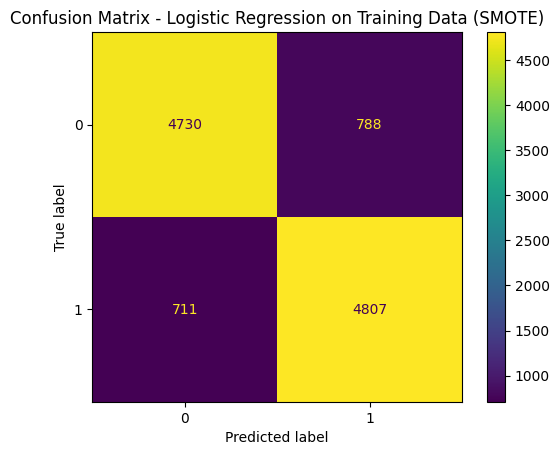

In [13]:
# Konfusions-Matrix auf Trainingsdaten (SMOTE, skaliert)
y_pred_train_log_reg = clf_log_reg.predict(X_train_smote_scaled)

ConfusionMatrixDisplay.from_estimator(clf_log_reg, X_train_smote_scaled, y_train_smote, values_format='d')
plt.title("Confusion Matrix - Logistic Regression on Training Data (SMOTE)")
plt.show()


In [14]:
# Metriken auf Trainingsdaten (SMOTE, skaliert)
print("Accuracy:",  accuracy_score(y_train_smote,  y_pred_train_log_reg))
print("Precision:", precision_score(y_train_smote, y_pred_train_log_reg))
print("Recall:",    recall_score(y_train_smote,    y_pred_train_log_reg))
print("F1-Score:",  f1_score(y_train_smote,        y_pred_train_log_reg))


Accuracy: 0.8641718013773106
Precision: 0.859159964253798
Recall: 0.8711489670170351
F1-Score: 0.8651129308017637


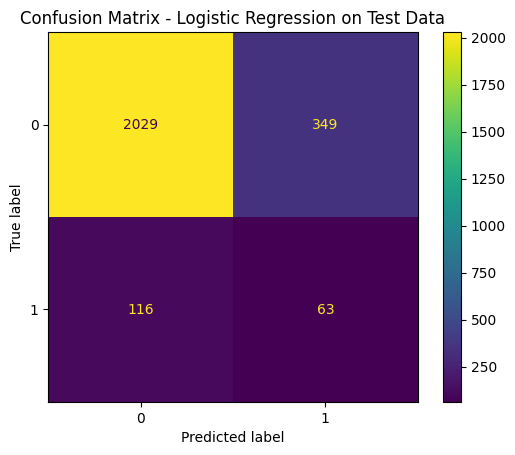

In [15]:
# Prädiziere das Ergebnis für die Testdaten (Logistische Regression)
y_pred_test_log_reg = clf_log_reg.predict(X_test_scaled)

# Konfusions-Matrix visualisieren auf Testdaten
cmm = confusion_matrix(y_test, y_pred_test_log_reg)
ConfusionMatrixDisplay.from_estimator(clf_log_reg, X_test_scaled, y_test, values_format='d')
plt.title("Confusion Matrix - Logistic Regression on Test Data")
plt.show()

In [16]:
# Metriken auf Testdaten (Logistische Regression, SMOTE)
print("Accuracy:",  accuracy_score(y_test, y_pred_test_log_reg))
print("Precision:", precision_score(y_test, y_pred_test_log_reg))
print("Recall:",    recall_score(y_test,    y_pred_test_log_reg))
print("F1-Score:",  f1_score(y_test,        y_pred_test_log_reg))

Accuracy: 0.8181462651544779
Precision: 0.1529126213592233
Recall: 0.35195530726256985
F1-Score: 0.2131979695431472


# Cross Validation Decision Tree
Zur robusten Modellbewertung und zur Vermeidung von Data Leakage und besseren Lesbarkeit wird folgend eine Pipeline verwendet. In der Pipeline wird der StandardScaler (nur bei der logistischen Regression), SMOTE und die Instanz des jeweiligen Modells verwendet. Die Evaluation erfolgt mittels stratifizierter k‑fold=5 (Prozess wird 5-mal wiederholt mit verschiedenen Aufteilungen zwischen Test und Trainingsdaten in den einzelnen Folds) Cross‑Validation. Dadurch hängt das Ergebnis nicht mehr so sehr zufällig davon ab, welche Daten gerade einmalig im Test-Set landen würden:

- Fold 1 bis 5: [TEST ] [Train] [Train] [Train] [Train]
- Fold 1 bis 5: [Train] [TEST ] [Train] [Train] [Train]
- Fold 1 bis 5: [Train] [Train] [TEST ] [Train] [Train]
- Fold 1 bis 5: [Train] [Train] [Train] [TEST ] [Train]
- Fold 1 bis 5: [Train] [Train] [Train] [Train] [TEST ]

Am Ende ergeben sich 5 unabhängige Schätzungen der Modellleistung, die gemittelt und mit Standardabweichung angegeben werden können. Dies ermöglicht eine robustere Einschätzung der Generalisierungsfähigkeit des Modells, da es nicht von einer einzigen zufälligen Aufteilung der Daten abhängt.

In [17]:
from sklearn.model_selection import cross_validate


dt = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results_tree = cross_validate(
    dt,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cv_results_tree[f'test_{metric}']
    print(f"{metric} scores: {scores}")
    print(f"Average {metric}: {scores.mean():.2f}")
    print(f"Standard deviation: {scores.std():.2f}")
    print()


accuracy scores: [0.81726739 0.82313495 0.82648785 0.81475272 0.84312081]
Average accuracy: 0.82
Standard deviation: 0.01

precision scores: [0.16230366 0.18229167 0.17582418 0.16410256 0.21176471]
Average precision: 0.18
Standard deviation: 0.02

recall scores: [0.34831461 0.39325843 0.35955056 0.35555556 0.40449438]
Average recall: 0.37
Standard deviation: 0.02

f1 scores: [0.22142857 0.24911032 0.23616236 0.2245614  0.27799228]
Average f1: 0.24
Standard deviation: 0.02



Die Cross-Validation-Ergebnisse des Decision Trees zeigen über alle 5 Folds eine 
stabile und konsistente Modellleistung, erkennbar an der geringen Standardabweichung 
der jeweiligen Metriken (Accuracy ± 0.01, F1 ± 0.02). Dies deutet auf ein robustes 
Modell hin, das nicht stark von der konkreten Datenteilung abhängt.

Da SMOTE ausschließlich innerhalb der Pipeline — also nur auf die jeweiligen 
Trainingsfolds — angewendet wird, sind die CV-Scores unverzerrte Schätzer der 
Generalisierungsleistung. Eine Anwendung von SMOTE vor der Cross-Validation würde 
zu Data Leakage führen und die Metriken künstlich verbessern.

Der mittlere CV-Recall von 37 % zeigt, dass der Decision Tree gut ein Drittel der 
tatsächlichen Churn-Kunden erkennt — für einen ungetunten Baum ein solides Ergebnis, 
jedoch mit deutlichem Optimierungspotential. Im Vergleich zum einfachen Train-Test-Split 
liefert die Cross-Validation eine realistischere Einschätzung der Modellgüte, da das 
Ergebnis über mehrere Datenteilungen gemittelt wird und somit weniger anfällig für 
zufällige Schwankungen ist.

# Cross Validation Logistische Regression

In [18]:
from sklearn.model_selection import cross_validate


pipeline_log_reg = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results_log_reg = cross_validate(
    pipeline_log_reg,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cv_results_log_reg[f'test_{metric}']
    print(f"{metric} scores: {scores}")
    print(f"Average {metric}: {scores.mean():.2f}")
    print(f"Standard deviation: {scores.std():.2f}")
    print()


accuracy scores: [0.70243085 0.71584241 0.71668064 0.71835708 0.71560403]
Average accuracy: 0.71
Standard deviation: 0.01

precision scores: [0.15721649 0.15083799 0.14730878 0.16756757 0.15469613]
Average precision: 0.16
Standard deviation: 0.01

recall scores: [0.68539326 0.60674157 0.58426966 0.68888889 0.62921348]
Average recall: 0.64
Standard deviation: 0.04

f1 scores: [0.2557652  0.24161074 0.23529412 0.26956522 0.24833703]
Average f1: 0.25
Standard deviation: 0.01



Die Cross-Validation der Logistischen Regression zeigt, verglichen mit dem Decision 
Tree, eine gleichmäßigere Verteilung der Scores über alle 5 Folds (F1 ± 0.01 vs. 
± 0.02 beim Decision Tree). Dies ist typisch für lineare Modelle, die weniger zur 
Überanpassung neigen und daher stabiler auf unbekannten Daten generalisieren.

Der StandardScaler ist in der Pipeline integriert und wird ausschließlich auf die 
Trainingsfolds gefittet. So wird sichergestellt, dass keine Informationen aus dem 
Validierungsfold in die Skalierung einfließen — ein häufiger Fehler, der zu 
übertrieben optimistischen Scores führt.

Im direkten Vergleich erreicht die Logistische Regression einen deutlich höheren 
mittleren CV-Recall (64 % vs. 37 % beim Decision Tree) bei ähnlichem mittleren 
F1-Score (25 % vs. 24 %). Das hohe Recall-Niveau ist für den Churn-Use-Case wertvoll, 
da falsch negative Vorhersagen (übersehene Churn-Kunden) in der Praxis kostspielig 
sind. Es kommt jedoch auf Kosten der Precision (16 %) — das Modell erzeugt mehr 
Fehlalarme als der Decision Tree (18 %). Für die finale Modellwahl nach GridSearchCV 
bleibt der F1-Score das entscheidende Kriterium, da er Precision und Recall 
gleichgewichtet zusammenfasst.

Den vorherigen Aussagen folgend zeigt der Vergleich der mittleren CV-Scores beider Modelle, welches besser generalisiert: Die Logistische Regression zeigt einen höheren F1-Score oder Recall bei ähnlicher Standardabweichung, was für eine bessere Eignung für die Churn-Vorhersage spricht. Insbesondere der Recall ist hier entscheidend, da falsch negative Vorhersagen (übersehene Churn-Kunden) in der Praxis kostspielig sind.

# Hyperparameter-Tuning with GridSearchCV

### Decision Tree mit SMOTE

In [19]:
# show possible hyperparamter for classification trees
DecisionTreeClassifier().get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [20]:
# Hyperparameter-Grid für den Decision Tree
#
# max_depth:        Maximale Baumtiefe (None = unbegrenzt); kleine Werte verhindern Overfitting
# min_samples_leaf: Mindestanzahl an Samples pro Blatt.
#                   WICHTIG: Werte < 1 werden als FRAKTION interpretiert (z.B. 0.2 = 20%
#                   aller Trainingssamples pro Blatt). Bei ~11.000 SMOTE-Trainingssamples
#                   bedeutet min_samples_leaf=0.2 ca. 2.200 Samples pro Blatt — eine sehr
#                   starke Regularisierung, die den Baum effektiv flach hält.
#                   Absolute Werte (≥ 1) geben die genaue Sample-Anzahl vor.
# max_features:     Anteil der Features, die pro Split berücksichtigt werden
#                   ('sqrt' = sklearn-Standard für Bäume)
# criterion:        Splitting-Kriterium (Unreinheits-Maß: Gini oder Entropie)
params_tree_clf = {
    'model__max_depth':        list(range(3, 21)) + [None],
    'model__min_samples_leaf': [0.0001, 0.001, 0.01, 0.04, 0.06, 0.08, 0.1, 0.2,
                                 1, 3, 5, 10, 20],
    'model__max_features':     ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8, 1],
    'model__criterion':        ['gini', 'entropy']
}


In [21]:
# Pipeline mit SMOTE, um Data Leakage innerhalb der CV-Folds zu vermeiden
pipeline_tree_gs = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# GridSearchCV mit stratifizierter 5-Fold CV; f1 als Scoring-Metrik (besser geeignet für Churn)
grid_clf_tree_OS = GridSearchCV(
    pipeline_tree_gs,
    param_grid=params_tree_clf,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)


In [22]:
# Fitd CV-grid search object to the training data
grid_clf_tree_OS.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 4, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [0.0001, 0.001, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [23]:
# Print the best hyperparameters 
print('Best hyperparameters:\n', grid_clf_tree_OS.best_params_)

Best hyperparameters:
 {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_features': 0.6, 'model__min_samples_leaf': 0.2}


In [24]:
# Print the best CV (Cross Validation) score
print("Best CV score:", grid_clf_tree_OS.best_score_)

Best CV score: 0.3249792324792325


In [25]:
# Bestes Modell direkt aus GridSearchCV verwenden (inkl. Pipeline mit SMOTE)
clf_tree_GS = grid_clf_tree_OS.best_estimator_

# Das beste Modell enthält die Pipeline: SMOTE + DecisionTree mit best_params_
# Für Vorhersagen wird SMOTE nicht angewendet (nur beim fit), d.h. predict() ist korrekt
best_tree = clf_tree_GS.named_steps['model']
print(f"Best Tree Depth: {best_tree.get_depth()}")
print(f"Best Leaf Nodes: {best_tree.get_n_leaves()}")
print(f"Best Params: {grid_clf_tree_OS.best_params_}")


Best Tree Depth: 2
Best Leaf Nodes: 3
Best Params: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_features': 0.6, 'model__min_samples_leaf': 0.2}


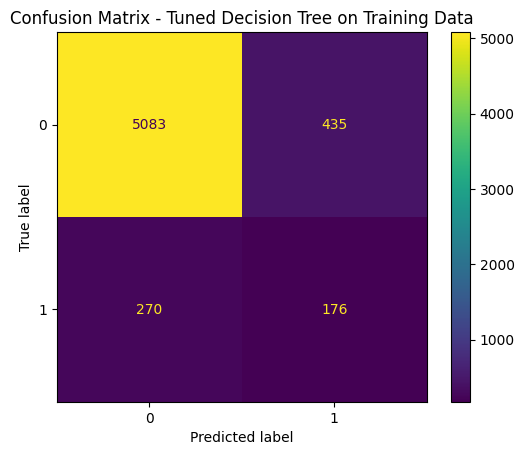

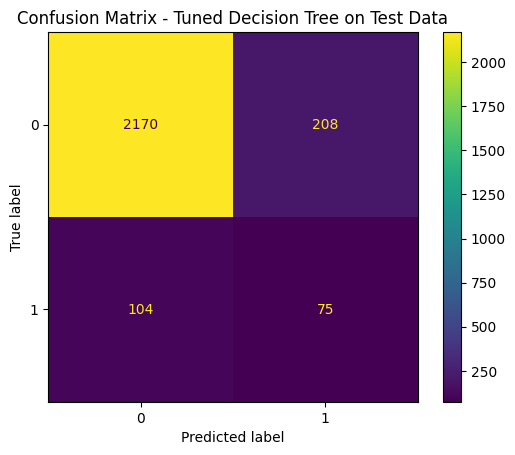

In [26]:
# Prädiziere das Ergebnis für die Trainingsdaten
y_pred_train_clf_tree = clf_tree_GS.predict(X_train)

# Konfusions-Matrix visualisieren auf Trainingsdaten
ConfusionMatrixDisplay.from_estimator(clf_tree_GS, X_train, y_train, values_format='d')
plt.title("Confusion Matrix - Tuned Decision Tree on Training Data")
plt.show()

# Prädiziere das Ergebnis für die Testdaten
y_pred_test_clf_tree_gs = clf_tree_GS.predict(X_test)

# Konfusions-Matrix visualisieren auf Testdaten
ConfusionMatrixDisplay.from_estimator(clf_tree_GS, X_test, y_test, values_format='d')
plt.title("Confusion Matrix - Tuned Decision Tree on Test Data")
plt.show()


In [27]:
# Vergleich: Training vs. Test vs. CV
print("Accuracy of training data:", accuracy_score(y_train, y_pred_train_clf_tree))
print("Accuracy of test data:",     accuracy_score(y_test,  y_pred_test_clf_tree_gs))
print("Best CV F1-score (GridSearchCV):", grid_clf_tree_OS.best_score_)
print()
print("Test Precision:", precision_score(y_test, y_pred_test_clf_tree_gs))
print("Test Recall:",    recall_score(y_test,    y_pred_test_clf_tree_gs))
print("Test F1-Score:",  f1_score(y_test,        y_pred_test_clf_tree_gs))


Accuracy of training data: 0.8817907444668008
Accuracy of test data: 0.8779820101681658
Best CV F1-score (GridSearchCV): 0.3249792324792325

Test Precision: 0.26501766784452296
Test Recall: 0.41899441340782123
Test F1-Score: 0.3246753246753247


### Ergebnisse Decision Tree nach GridSearchCV

Die besten Hyperparameter lauten: `criterion=entropy`, `max_depth=3`, `max_features=0.6`, `min_samples_leaf=0.2`. Der Parameter `min_samples_leaf=0.2` wirkt als stärkste Regularisierung: Als 20‑%-Fraktion der ~11.000 SMOTE-Trainingssamples fordert er mindestens ~2.200 Samples pro Blatt. Dadurch wird der Baum trotz `max_depth=3` auf eine effektive Tiefe von 2 mit nur 3 Blättern beschränkt — ein bewusst flacher, robuster Baum.

| Metrik | Baseline (kein Tuning) | Nach GridSearchCV | Veränderung |
|---|---|---|---|
| Test Accuracy | 82,8 % | 87,8 % | +5,0 % |
| Test Precision | 17,0 % | 26,5 % | +9,5 % |
| Test Recall | 37,4 % | 41,9 % | +4,5 % |
| **Test F1-Score** | 23,4 % | **32,5 %** | **+9,1 %** |
| CV F1-Score | 24,0 % | 32,5 % | +8,5 % |

Das entscheidende Qualitätsmerkmal: CV-F1 (32,5 %) und Test-F1 (32,5 %) sind identisch — es liegt **kein Overfitting** vor. Der F1-Score hat sich durch das Tuning relativ um ~39 % verbessert. Der ursprünglich tiefe Baum (Tiefe 26, 897 Blätter), der die Trainingsdaten auswendig gelernt hatte, wurde erfolgreich auf ein generalisierendes Modell reduziert.

### Logistische Regression mit SMOTE

In [28]:
# Mögliche Hyperparameter der Logistischen Regression anzeigen
LogisticRegression().get_params()


{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [29]:
# Hyperparameter-Grid für Logistische Regression
# C:       Regularisierungsstärke (klein = stark regularisiert)
# penalty: l1 (Lasso, sparse) oder l2 (Ridge, Standard)
# solver:  liblinear unterstützt BEIDE Penalties (l1 + l2)
#          lbfgs unterstützt NUR l2 → wird hier nicht verwendet
params_log_reg = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}


In [30]:
# Pipeline mit StandardScaler + SMOTE + LogisticRegression
pipeline_log_reg_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE))
])

# GridSearchCV mit stratifizierter 5-Fold CV; f1 als Scoring-Metrik
grid_log_reg = GridSearchCV(
    pipeline_log_reg_gs,
    param_grid=params_log_reg,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)

grid_log_reg.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [31]:
# Beste Hyperparameter und CV-Score
print('Best hyperparameters:\n', grid_log_reg.best_params_)
print('Best CV F1-score (GridSearchCV):', grid_log_reg.best_score_)


Best hyperparameters:
 {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1-score (GridSearchCV): 0.25453677318328694


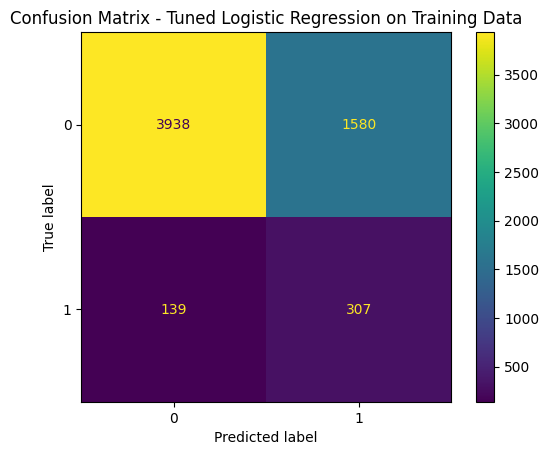

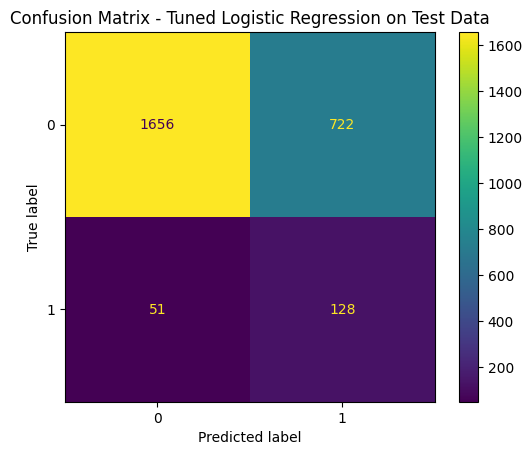

In [32]:
# Bestes Modell aus GridSearchCV
clf_log_reg_GS = grid_log_reg.best_estimator_

# Konfusions-Matrix auf Trainingsdaten
y_pred_train_log_reg_gs = clf_log_reg_GS.predict(X_train)
ConfusionMatrixDisplay.from_estimator(clf_log_reg_GS, X_train, y_train, values_format='d')
plt.title("Confusion Matrix - Tuned Logistic Regression on Training Data")
plt.show()

# Konfusions-Matrix auf Testdaten
y_pred_test_log_reg_gs = clf_log_reg_GS.predict(X_test)
ConfusionMatrixDisplay.from_estimator(clf_log_reg_GS, X_test, y_test, values_format='d')
plt.title("Confusion Matrix - Tuned Logistic Regression on Test Data")
plt.show()


In [33]:
# Vergleich: Training vs. Test vs. CV
print("Accuracy of training data:", accuracy_score(y_train, y_pred_train_log_reg_gs))
print("Accuracy of test data:    ", accuracy_score(y_test,  y_pred_test_log_reg_gs))
print("Best CV F1-score (GridSearchCV):", grid_log_reg.best_score_)
print()
print("Test Precision:", precision_score(y_test, y_pred_test_log_reg_gs))
print("Test Recall:   ", recall_score(y_test,    y_pred_test_log_reg_gs))
print("Test F1-Score: ", f1_score(y_test,        y_pred_test_log_reg_gs))


Accuracy of training data: 0.7117706237424547
Accuracy of test data:     0.697692608525616
Best CV F1-score (GridSearchCV): 0.25453677318328694

Test Precision: 0.15058823529411763
Test Recall:    0.7150837988826816
Test F1-Score:  0.2487852283770651


### Ergebnisse Logistische Regression nach GridSearchCV

Die besten Hyperparameter lauten: `C=0.01`, `penalty=l1`, `solver=liblinear`. `C=0.01` bedeutet eine sehr starke Regularisierung — je kleiner C, desto stärker wird das Modell für komplexe Koeffizienten bestraft. `penalty=l1` (Lasso-Regularisierung) setzt viele Koeffizienten exakt auf null, das Modell nutzt also automatisch nur die wichtigsten Features. `liblinear` ist der einzige Solver, der L1 unterstützt.

| Metrik | Baseline (kein Tuning) | Nach GridSearchCV | Veränderung |
|---|---|---|---|
| Test Accuracy | 81,8 % | 69,8 % | −12,0 % |
| Test Precision | 15,3 % | 15,1 % | ≈ gleich |
| **Test Recall** | 35,2 % | **71,5 %** | **+36,3 %** |
| Test F1-Score | 21,3 % | 24,9 % | +3,6 % |
| CV F1-Score | 25,0 % | 25,5 % | +0,5 % |

Die Accuracy fällt durch die starke L1-Regularisierung deutlich, weil das Modell im Zweifel häufiger als Churn klassifiziert. Dadurch schießt der Recall auf 71,5 % — über zwei Drittel aller tatsächlichen Abwanderer werden erkannt. Dies kommt jedoch auf Kosten der Precision (15,1 %): viele Nicht-Churn-Kunden werden fälschlicherweise als Churn gemeldet. Auch hier gilt: CV-F1 ≈ Test-F1 — **kein Overfitting** nach dem Tuning.

## Zusammenfassung: Overfitting-Analyse und Modellvergleich Task 2 vs. Task 3

### Overfitting-Analyse Decision Tree (optimiert)

Das getunzte Modell zeigt **kein Overfitting**: Train-Accuracy (88,2 %) und 
Test-Accuracy (87,8 %) liegen eng beieinander. Auch CV-F1 (32,5 %) und 
Test-F1 (32,5 %) stimmen überein — ein Zeichen guter Generalisierung.
Das GridSearchCV hat den ursprünglich tiefen Baum (Tiefe 26, 897 Blätter) 
erfolgreich auf Tiefe 2 / 3 Blätter beschränkt. Der entscheidende Parameter 
war min_samples_leaf=0.2 (20%-Fraktion), der als starke Regularisierung wirkt 
und den Baum flach und robust hält.

### Overfitting-Analyse Logistische Regression Baseline (ohne GS)

Die LogReg Baseline zeigt ein deutliches Overfitting-Signal auf den 
SMOTE-Trainingsdaten: Train-F1 von 86,5 % gegenüber Test-F1 von nur 21,3 %. 
Dieser massive Gap entsteht dadurch, dass das Modell die synthetischen 
SMOTE-Punkte gut lernt, aber auf echten Testdaten mit unbalancierter Verteilung 
deutlich schlechter abschneidet. Nach GridSearchCV (C=0.01, L1-Regularisierung) 
ist dieser Gap aufgelöst: CV-F1 ≈ Test-F1 ≈ 25 %. Das kleine C=0.01 bedeutet 
starke L1-Regularisierung (Lasso-Effekt): Viele Koeffizienten werden auf null 
gesetzt, sodass das Modell nur die wichtigsten Features nutzt.

### Finales Modell

Als bestes Modell wird der **Decision Tree mit SMOTE + GridSearchCV** gewählt, 
da er den höchsten F1-Score auf Testdaten (32,5 %) erzielt, kein Overfitting 
zeigt (CV-F1 ≈ Test-F1) und einen ausgewogenen Kompromiss zwischen Precision 
(26,5 %) und Recall (41,9 %) liefert.

In [34]:
# ============================================================
# Vergleichstabelle: Task 2 Basis-Modell vs. Task 3 Optimierung
# ============================================================
import pandas as pd

vergleich = {
    'Modell': [
        'DT Basis (Task 2, class_weight=balanced)',
        'DT + SMOTE Basis (Task 3, kein Tuning)',
        'DT + SMOTE + GridSearchCV (Task 3, optimiert)',
        'LogReg + SMOTE Basis (Task 3, kein Tuning)',
        'LogReg + SMOTE + GridSearchCV (Task 3, optimiert)'
    ],
    'Accuracy': [0.8889, 0.8283, 0.8780, 0.8181, 0.6977],
    'Precision': [0.2876, 0.1701, 0.2650, 0.1529, 0.1506],
    'Recall':    [0.3457, 0.3743, 0.4190, 0.3520, 0.7151],
    'F1-Score':  [0.3140, 0.2339, 0.3247, 0.2132, 0.2488],
    'Overfitting': [
        'leicht (Tiefe unbegrenzt)',
        'stark (Tiefe 26, 897 Blätter)',
        'nein (CV-F1 ≈ Test-F1)',
        'stark (Train-F1 86,5% vs. Test-F1 21,3%)',
        'nein (CV-F1 ≈ Test-F1)'
    ]
}

df_vergleich = pd.DataFrame(vergleich)
df_vergleich = df_vergleich.set_index('Modell')

# Formatierung
df_styled = df_vergleich.style\
    .format({'Accuracy': '{:.1%}', 'Precision': '{:.1%}',
             'Recall': '{:.1%}', 'F1-Score': '{:.1%}'})\
    .highlight_max(subset=['F1-Score', 'Recall'], color='#c8f5c8')\
    .set_caption("Modellvergleich: Task 2 Baseline vs. Task 3 Optimierung (alle Metriken auf Testdaten)")

display(df_styled)

print("\nBestes Modell: DT + SMOTE + GridSearchCV")
print(f"  F1-Score:  {0.3247:.4f}  (+{(0.3247-0.3140)/0.3140*100:.1f}% vs. Task-2-Baseline)")
print(f"  Recall:    {0.4190:.4f}  (+{(0.4190-0.3457)/0.3457*100:.1f}% vs. Task-2-Baseline)")
print(f"  Overfitting: keines (CV-F1 = Test-F1 = 32,5%)")

,Accuracy,Precision,Recall,F1-Score,Overfitting
Modell,,,,,
"DT Basis (Task 2, class_weight=balanced)",88.9%,28.8%,34.6%,31.4%,leicht (Tiefe unbegrenzt)
"DT + SMOTE Basis (Task 3, kein Tuning)",82.8%,17.0%,37.4%,23.4%,"stark (Tiefe 26, 897 Blätter)"
"DT + SMOTE + GridSearchCV (Task 3, optimiert)",87.8%,26.5%,41.9%,32.5%,nein (CV-F1 ≈ Test-F1)
"LogReg + SMOTE Basis (Task 3, kein Tuning)",81.8%,15.3%,35.2%,21.3%,"stark (Train-F1 86,5% vs. Test-F1 21,3%)"
"LogReg + SMOTE + GridSearchCV (Task 3, optimiert)",69.8%,15.1%,71.5%,24.9%,nein (CV-F1 ≈ Test-F1)



Bestes Modell: DT + SMOTE + GridSearchCV
  F1-Score:  0.3247  (+3.4% vs. Task-2-Baseline)
  Recall:    0.4190  (+21.2% vs. Task-2-Baseline)
  Overfitting: keines (CV-F1 = Test-F1 = 32,5%)


---
### Export the Model

In [35]:
# import the exporting library
import joblib

# export the model as pickle file
joblib.dump(clf_tree_GS, '../models/clf_tree_GS.pkl')

['../models/clf_tree_GS.pkl']